# Exploring Data with Python

Joan Zheng
QCL Graduate Fellow
Claremont McKenna College

Thank you so much for coming to my workshop!

This is a Level 2 Workshop, so I will assume you are familiar with the topics covered in the **Practical Programming with Python** Workshop (Level 1):

* Basics of Jupyter notebook
* Variables
* Functions
* Lists and dictionaries
* For loops
* Conditional statements

By the end of this workshop you will be able to:

* Import and export data
* Explore and subset DataFrames
* Detect and deal with missing data
* Create basic visualizations with Pandas
* Apply Principal Component Analysis (PCA) with NumPy
* Change between data types

## Jupyter Notebooks review

To run the selected cells, press `Ctrl + Enter` on Windows or `⌘ + Enter` on Mac. You may also press the "play" button on the left.

A Code cell will evaluate Python code and show the result (if there's anything to show).

## Today's datasets

### Iris Dataset
We will use the classic [Iris dataset](https://archive.ics.uci.edu/dataset/53/iris).

The Iris flower dataset is also known as the Fisher's Iris dataset. This is the same Fisher, Sir Ronald Aylmer Fisher, who also invented Fisher's exact test.

As a Fellow of the Royal Society, Sir Fisher was born in 1890 in London, England, and was well-known as a statistician and geneticist.

The goal for today is to explore and clean datasets using Pandas and NumPy.

For the rest of this workshop, we will use the Iris dataset for all examples, including subsetting, duplicates, and missing-data handling.

## Pandas, Numpy and Matplotlib

Pandas is a powerful and flexible library used for data exploration and transformation. Pandas is built on top of NumPy and uses DataFrames as its main data structure. NumPy (Numerical Python) provides the tools for efficient numerical computation (e.g. matrix multiplication) and uses multidimensional arrays as its data structure. Matplotlib is a plotting library that helps us visualize data through charts such as line plots, bar charts, histograms, and scatter plots.

|                         Pandas                        |                   NumPy                  |                    Matplotlib                    |
|:-----------------------------------------------------:|:----------------------------------------:|:------------------------------------------------:|
|          Uses a 2D data structure (DataFrame)         | Capable of using multidimensional arrays | Used for plotting and data visualization         |
|               Slower compared with NumPy              |            Faster than Pandas            | Flexible and customizable chart formatting       |
| Columns in a DataFrame can be of different data types | Arrays can only be of one data type      | Works well with Pandas Series/DataFrames and NumPy arrays |

To use a library in Python, we first need to import it using an `import` statement. In this workshop, we will use NumPy for numerical operations, Pandas for tabular data handling, and Matplotlib for visualization.

In [1]:
# Import NumPy
import numpy

print(numpy.__version__)
print(numpy.pi)

2.4.3
3.141592653589793


In [2]:
# Import with aliases
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Pandas DataFrames

A DataFrame is a 2D data structure where each column can be of a different type. Both, rows and columns are labeled.

### Create a DataFrame

One way to construct a DataFrame is by using a dictionary.

In [3]:
# Create a dictionary with Iris-style sample data
iris_dict = {
    "sepal_length": [5.1, 4.9, 6.3],
    "sepal_width": [3.5, 3.0, 3.3],
    "petal_length": [1.4, 1.4, 6.0],
    "petal_width": [0.2, 0.2, 2.5],
    "species": ["setosa", "setosa", "virginica"]
}

# Create the DataFrame
df_sample = pd.DataFrame(iris_dict)
df_sample

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,6.3,3.3,6.0,2.5,virginica


Creating DataFrames by hand is useful for testing purposes. However, in most cases we will need to read our data from a CSV (Comma Separated Values) file or any other file format.

### Importing data

Pandas has many functions to import data from different sources. For example, we can read CSV files using the `read_csv()` function.

In [4]:
# Read Iris data
df_iris = pd.read_csv(
    "content/Iris.csv",
    names=["sepal_length", "sepal_width", "petal_length", "petal_width", "species"],
    header=0
)
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<div class="alert alert-block alert-warning">
    <b>Note:</b> Pandas also has functions to read Excel files (<code>read_excel()</code>) and even SQL files (<code>read_sql()</code>).
</div>

### Exploring your DataFrame

Our Iris-based workshop DataFrame is larger than our first DataFrame created from a dictionary, so printing everything will not actually show every data point.

In [5]:
# Display the output
df_iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
176,6.7,3.0,NaN,2.3,Iris-virginica
177,6.3,2.5,5.0,1.9,Iris-virginica
178,6.5,3.0,5.2,2.0,Iris-virginica
179,6.2,3.4,5.4,2.3,Iris-virginica


However, we can explore our dataset using some useful Pandas functions. The `head()` function will print the first 5 rows of our DataFrame by default.

In [6]:
# Preview the first rows
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


We can also obtain the dimensions of our DataFrame using `shape`.

In [7]:
# Check the DataFrame dimensions
df_iris.shape

(181, 5)

<div class="alert alert-block alert-warning">
    <b>Note:</b> While <code>head()</code> is a method (i.e. a function associated with a Pandas DataFrame), <code>shape</code> is an attribute. This is why we do not use parentheses.
</div>

We can also access the full list of column names of our DataFrame using `columns`.

In [8]:
# List DataFrame column names
df_iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

To generate descriptive statistics of our DataFrame, we can use the `describe()` function.

In [9]:
# Show descriptive statistics
df_iris.describe(include="all")

,sepal_length,sepal_width,petal_length,petal_width,species
count,179.000000,178.000000,180.000000,177.000000,181
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,76
mean,5.760335,3.109551,3.445556,1.088701,NaN
std,0.800521,0.431092,1.820839,0.781961,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.500000,0.200000,NaN
50%,5.700000,3.100000,4.000000,1.200000,NaN
75%,6.300000,3.400000,5.000000,1.800000,NaN


The `info()` function prints a summary  of the DataFrame including the columns' data types (Dtype) and a Non-Null count.


In [10]:
# Display DataFrame summary information
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  179 non-null    float64
 1   sepal_width   178 non-null    float64
 2   petal_length  180 non-null    float64
 3   petal_width   177 non-null    float64
 4   species       181 non-null    str    
dtypes: float64(4), str(1)
memory usage: 9.5 KB


If missing values appear in our Iris dataset, we can detect and handle them with Pandas.

Some of the Pandas data types you may encounter are:

| Pandas dtype |                     Usage                    |
|:------------:|:--------------------------------------------:|
|    object    | Text or mixed numeric and non-numeric values |
|     int64    |                Integer numbers               |
|    float64   |            Floating point numbers            |
|     bool     |               True/False values              |

<div class="alert alert-block alert-success">
    <b>Hands-on:</b> Explore the Iris data set using <code>head()</code>, <code>describe()</code>, <code>info()</code>, <code>shape</code> and <code>columns</code>.
</div>

In [11]:
# Print the first 5 rows
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
# Print descriptive statistics
df_iris.describe(include="all")

,sepal_length,sepal_width,petal_length,petal_width,species
count,179.000000,178.000000,180.000000,177.000000,181
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,76
mean,5.760335,3.109551,3.445556,1.088701,NaN
std,0.800521,0.431092,1.820839,0.781961,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.500000,0.200000,NaN
50%,5.700000,3.100000,4.000000,1.200000,NaN
75%,6.300000,3.400000,5.000000,1.800000,NaN


In [13]:
# Print a summary of your data with info()
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  179 non-null    float64
 1   sepal_width   178 non-null    float64
 2   petal_length  180 non-null    float64
 3   petal_width   177 non-null    float64
 4   species       181 non-null    str    
dtypes: float64(4), str(1)
memory usage: 9.5 KB


In [14]:
# Print the dimensions of your dataset
df_iris.shape

(181, 5)

In [15]:
# Print the column names
df_iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

These functions give us general information about our data. However, we can also explore subsets of our data.

### Subsetting your DataFrame

We can select columns of the DataFrame using the column name

In [16]:
# Select the species
df_iris["species"]

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
176    Iris-virginica
177    Iris-virginica
178    Iris-virginica
179    Iris-virginica
180    Iris-virginica
Name: species, Length: 181, dtype: str

<div class="alert alert-block alert-warning">
<b>Note:</b> Each column in a DataFrame is a Pandas Series. We can think of a DataFrame as a dictionary of Pandas Series.
</div>

If we do not want all the rows we can use the `head()` function at the end. We can also select multiple columns by using a list of column names.

In [17]:
# Select multiple columns
df_iris[["sepal_length", "petal_length"]].head()

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4


Sometimes, it is useful to store the list of columns we want to access on a separate variable.

In [18]:
# Select multiple columns
selected_cols = ["sepal_width", "petal_width", "species"]
df_iris[selected_cols].head()

,sepal_width,petal_width,species
0,3.5,0.2,Iris-setosa
1,3.0,0.2,Iris-setosa
2,3.2,0.2,Iris-setosa
3,3.1,0.2,Iris-setosa
4,3.6,0.2,Iris-setosa


In [19]:
# Condition on petal length
df_iris[df_iris["petal_length"] > 5].head()

,sepal_length,sepal_width,petal_length,petal_width,species
112,6.0,2.7,5.1,1.6,Iris-versicolor
129,6.3,3.3,6.0,2.5,Iris-virginica
130,5.8,2.7,5.1,1.9,Iris-virginica
131,7.1,3.0,5.9,2.1,Iris-virginica
132,6.3,2.9,5.6,1.8,Iris-virginica


<div class="alert alert-block alert-warning">
    <b>Note:</b> Comparisons with missing values, encoded as <code>NaN</code>, will return <code>False</code>.
</div>

We can use this to select only the rows where petal length is below a threshold.


In [20]:
# Create variables for this step
small_petal = df_iris["petal_length"] <= 2.0
short_petal_iris = df_iris[small_petal]
short_petal_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


If instead we wanted to retrieve Iris rows with short petals and wide sepals, we can use multiple conditions.


In [21]:
# Create variables for this step
short_petals = df_iris["petal_length"] < 3.0
wide_sepals = df_iris["sepal_width"] > 3.0

In [22]:
# Write code for this step
df_iris[short_petals & wide_sepals].head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa


The conditional operators in Pandas are:

| Operator | Pandas |
|:--------:|:------:|
|    and   |    &   |
|    or    |   \|   |
|   not    | ~      |

To select rows based on text data, we can use the `==` operator.

In [23]:
# Select the rows for Iris-versicolor
df_iris[df_iris["species"] == "versicolor"].head()

,sepal_length,sepal_width,petal_length,petal_width,species


If we are using the `==` operator, instead of using multiple conditions to check for equality, we can use the `isin()` function.

In [24]:
# Select multiple titles with conditions
df_iris[(df_iris["species"] == "setosa") | (df_iris["species"] == "virginica")].head()

,sepal_length,sepal_width,petal_length,petal_width,species


In [25]:
# Select multiple titles with isin()
df_iris[df_iris["species"].isin(["setosa", "virginica"])].head()

,sepal_length,sepal_width,petal_length,petal_width,species


This also works for any other data type, not just text.

In [26]:
# Select rows where petal length is 1.4 or 4.7 using isin()
df_iris[df_iris["petal_length"].isin([1.4, 4.7])].head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa


<div class="alert alert-block alert-success">
    <b>Hands-on:</b>
<ol>
    <li>Print the first 5 rows of the <code>"sepal_length"</code>, <code>"sepal_width"</code>, and <code>"species"</code> columns.</li>
    <li>Select rows for species <code>"setosa"</code> and <code>"versicolor"</code> and print the first 5 rows.</li>
    <li>Select rows where <code>petal_length</code> is greater than 5.</li>
</ol>
</div>

In [27]:
# Print the first 5 rows of sepal_length, sepal_width, and species.
df_iris[["sepal_length", "sepal_width", "species"]].head()

,sepal_length,sepal_width,species
0,5.1,3.5,Iris-setosa
1,4.9,3.0,Iris-setosa
2,4.7,3.2,Iris-setosa
3,4.6,3.1,Iris-setosa
4,5.0,3.6,Iris-setosa


In [28]:
# Select setosa and versicolor rows and print the first 5.
df_iris[df_iris["species"].isin(["setosa", "versicolor"])].head()

,sepal_length,sepal_width,petal_length,petal_width,species


In [29]:
# Select rows where petal_length is greater than 5.
df_iris[df_iris["petal_length"] > 5].head()

,sepal_length,sepal_width,petal_length,petal_width,species
112,6.0,2.7,5.1,1.6,Iris-versicolor
129,6.3,3.3,6.0,2.5,Iris-virginica
130,5.8,2.7,5.1,1.9,Iris-virginica
131,7.1,3.0,5.9,2.1,Iris-virginica
132,6.3,2.9,5.6,1.8,Iris-virginica


You may have not noticed, but there are duplicate rows in our Iris dataset. Since we intentionally added repeats, we should detect and remove them.

In [30]:
# The duplicated() method returns a Series of boolean values
df_iris.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
176    False
177    False
178    False
179    False
180    False
Length: 181, dtype: bool

In [31]:
# Check if there is any duplicated row
df_iris.duplicated().any()

np.True_

In [32]:
# See duplicated rows
df_iris[df_iris.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
19,5.1,3.5,1.4,0.3,Iris-setosa
33,5.4,3.4,1.7,0.2,Iris-setosa
34,5.4,3.4,1.7,0.2,Iris-setosa
35,5.4,3.4,1.7,0.2,Iris-setosa
36,5.4,3.4,1.7,0.2,Iris-setosa
38,5.4,3.4,1.7,0.2,Iris-setosa
40,5.1,3.7,1.5,0.4,Iris-setosa
41,5.1,3.7,1.5,0.4,Iris-setosa
42,5.1,3.7,1.5,0.4,Iris-setosa
57,4.9,3.1,1.5,0.1,Iris-setosa


In [33]:
# Remove duplicated rows
df_iris = df_iris.drop_duplicates().reset_index(drop=True)
df_iris.shape

(164, 5)

<div class="alert alert-block alert-success">
    <b>Hands-on:</b> Check for duplicates in the Iris dataset and remove them if present.
</div>

In [34]:
# Check and remove duplicated rows from Iris data
print("Duplicate rows:", df_iris.duplicated().sum())
df_iris = df_iris.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after cleaning:", df_iris.duplicated().sum())

Duplicate rows: 0
Duplicate rows after cleaning: 0


#### Location-based indexing

Pandas has two additional ways of indexing that allow us to select specified rows and columns: <code>.loc</code> and <code>.iloc</code>.

In [35]:
# Select one value with loc
df_iris.loc[0, "petal_length"]

np.float64(1.4)

In [36]:
# Select rows with loc using a condition
df_iris.loc[df_iris["species"] == "virginica", ["sepal_length", "petal_length"]].head()

,sepal_length,petal_length


In [37]:
# Examples with iloc
df_iris.iloc[:5, :3]

,sepal_length,sepal_width,petal_length
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


<div class="alert alert-block alert-success">
    <b>Hands-on:</b> Select <code>sepal_length</code>, <code>sepal_width</code>, <code>petal_length</code>, and <code>species</code> for rows where species is <code>setosa</code> or <code>versicolor</code>. Print the first few rows.
</div>

In [38]:
# Show setosa and versicolor rows with selected columns
cols = ["sepal_length", "sepal_width", "petal_length", "species"]
df_iris.loc[df_iris["species"].isin(["setosa", "versicolor"]), cols].head()

,sepal_length,sepal_width,petal_length,species


## Dealing with missing data

Missing values can impact calculations and downstream analysis. We should detect them early, understand where they occur, and choose a suitable strategy such as filtering or imputation.

In [39]:
# Show info and missing-value counts
df_iris.info()
df_iris.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  162 non-null    float64
 1   sepal_width   161 non-null    float64
 2   petal_length  163 non-null    float64
 3   petal_width   160 non-null    float64
 4   species       164 non-null    str    
dtypes: float64(4), str(1)
memory usage: 8.7 KB


sepal_length    2
sepal_width     3
petal_length    1
petal_width     4
species         0
dtype: int64

In [40]:
# Attempting to force a numeric Iris column to float may fail if missing values exist
try:
    df_iris["sepal_length"].astype(float)
except Exception as e:
    print(e)

In [41]:
# Replace missing values in key columns with their means
key_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df_iris[key_cols] = df_iris[key_cols].fillna(df_iris[key_cols].mean())
df_iris[key_cols].isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

<div class="alert alert-block alert-success">
    <b>Hands-on:</b> Replace missing values in <code>sepal_length</code>, <code>sepal_width</code>, and <code>petal_length</code> using their means. Use <code>np.nanmean()</code> and <code>fillna()</code>.
</div>

In [42]:
# Compute means for selected columns using np.nanmean
cols = ["sepal_length", "sepal_width", "petal_length"]
means = {col: np.nanmean(df_iris[col]) for col in cols}
means

{'sepal_length': np.float64(5.811728395061728),
 'sepal_width': np.float64(3.091304347826087),
 'petal_length': np.float64(3.596319018404908)}

In [43]:
# Create a dictionary with the column names as keys and means as values
col_means = {
    "sepal_length": np.nanmean(df_iris["sepal_length"]),
    "sepal_width": np.nanmean(df_iris["sepal_width"]),
    "petal_length": np.nanmean(df_iris["petal_length"]),
}
col_means

{'sepal_length': np.float64(5.811728395061728),
 'sepal_width': np.float64(3.091304347826087),
 'petal_length': np.float64(3.596319018404908)}

In [44]:
# Fill missing values using the dictionary
df_iris = df_iris.fillna(col_means)
df_iris[["sepal_length", "sepal_width", "petal_length"]].isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
dtype: int64

<div class="alert alert-block alert-warning">
    <b>Note:</b> You can also remove rows with missing values using <code>dropna()</code> with a <code>subset</code> argument.
</div>

In [45]:
# Select rows without missing values in key columns
df_iris.dropna(subset=["sepal_length", "sepal_width", "petal_length", "petal_width"]).head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Writing files

Finally, writing our results to a file may be necessary to share our work or continue the analysis elsewhere. With Pandas we can write DataFrames to CSV, Excel and other file formats.

In [53]:
# Write complete rows to CSV
df_iris.to_csv("content/iris_cleaned.csv", index=False)

<div class="alert alert-block alert-success">
    <b>Hands-on:</b> Select rows where <code>petal_length &gt; 4.5</code> and <code>sepal_width &gt; 3.0</code>. Save this subset to <code>selected_iris</code> and write it to an Excel file called <code>selected_iris.xlsx</code> inside the <code>content/</code> folder.
</div>

In [54]:
# Subset the DataFrame and save this to the variable selected_iris
selected_iris = df_iris[(df_iris["petal_length"] > 4.5) & (df_iris["sepal_width"] > 3.0)]

# Write to Excel
selected_iris.to_excel("content/selected_iris.xlsx", index=False)
selected_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
62,7.0,3.200000,4.7,1.40000,Iris-versicolor
64,6.9,3.100000,4.9,1.50000,Iris-versicolor
68,6.3,3.300000,4.7,1.60000,Iris-versicolor
82,5.9,3.200000,4.8,1.80000,Iris-versicolor
90,6.7,3.091304,5.0,1.15625,Iris-versicolor


## Basic visualizations with Pandas

Before reducing dimensions, it is helpful to visualize the original feature relationships. We will use Pandas plotting to inspect how measurements vary across species.

In [46]:
# Build a clean numeric view for plotting and PCA
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df_iris_clean = df_iris.dropna(subset=numeric_cols).copy()

In [47]:
# Create a shared color palette for every species
from matplotlib.colors import ListedColormap

species_order = df_iris_clean["species"].unique()
species_palette = dict(zip(species_order, plt.cm.viridis(np.linspace(0.15, 0.85, len(species_order)))))
species_cmap = ListedColormap(list(species_palette.values()))
species_codes = df_iris_clean["species"].map({s: i for i, s in enumerate(species_order)}).to_numpy()

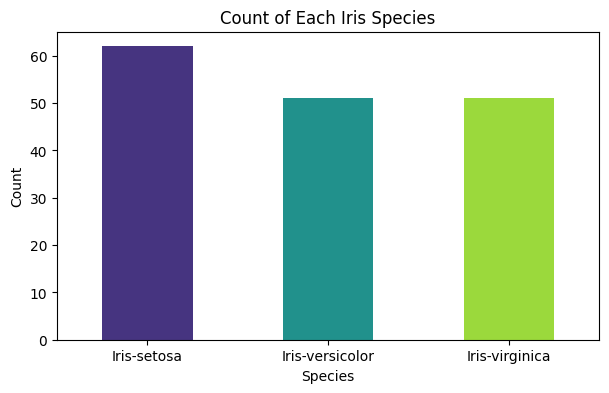

In [48]:
# Bar chart: count of each Iris species
counts = df_iris_clean["species"].value_counts().sort_index()
ax = counts.plot(kind="bar", color=[species_palette[s] for s in counts.index],
                 figsize=(7, 4), title="Count of Each Iris Species", ylabel="Count")
ax.set_xlabel("Species")
plt.xticks(rotation=0)
plt.show()

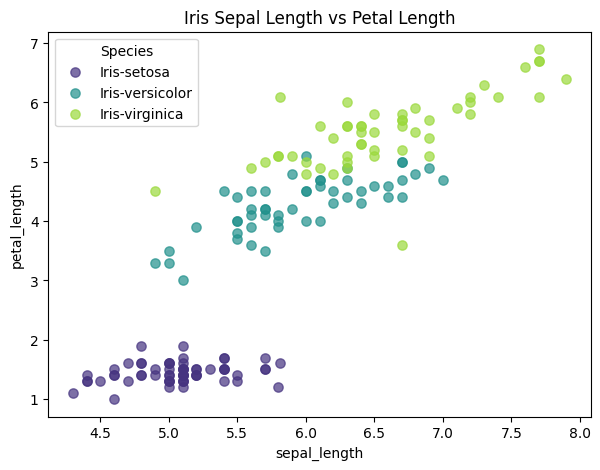

In [55]:
# Scatter plot before PCA
fig, ax = plt.subplots(figsize=(7, 5))
for species, color in species_palette.items():
    subset = df_iris_clean[df_iris_clean["species"] == species]
    ax.scatter(subset["sepal_length"], subset["petal_length"], 
               label=species, color=color, alpha=0.7, s=45)
ax.set(title="Iris Sepal Length vs Petal Length", 
       xlabel="sepal_length", ylabel="petal_length")
ax.legend(title="Species")
plt.show()

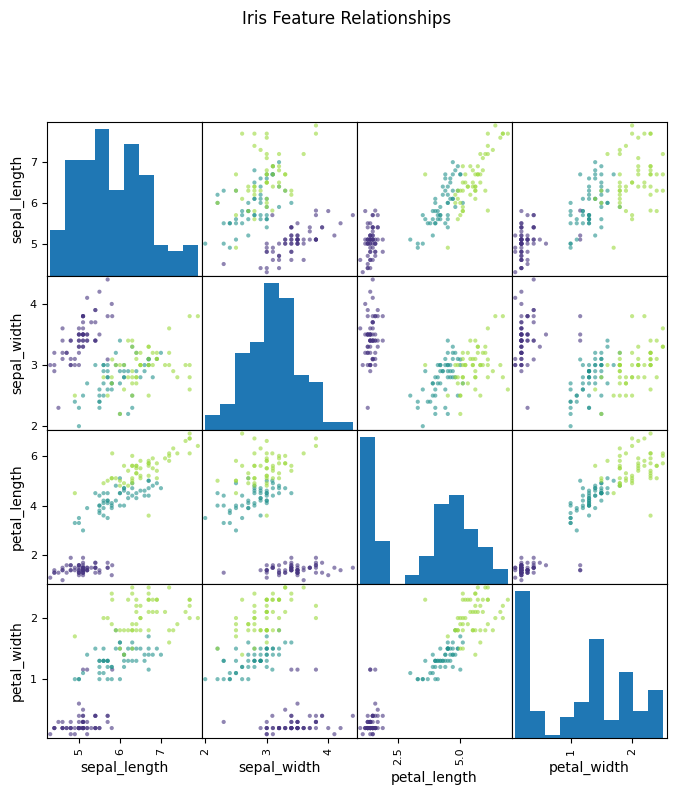

In [57]:
# Pairwise scatter matrix
pd.plotting.scatter_matrix(df_iris_clean[numeric_cols], figsize=(8, 8), 
                           alpha=0.6, diagonal="hist", c=species_codes, cmap=species_cmap)
plt.suptitle("Iris Feature Relationships", y=1.02)
plt.show()

## Principal Component Analysis (PCA) with NumPy

Now that the data is cleaned and visualized, we can reduce dimensionality with PCA.

Steps we will follow:
1. Create a numeric matrix from the Iris features.
2. Standardize each feature.
3. Compute the covariance matrix.
4. Get eigenvalues and eigenvectors with NumPy.
5. Project the data onto the first three principal components.

In [51]:
# PCA implementation with NumPy
X = df_iris_clean[numeric_cols].to_numpy()

# Standardize features (z-score)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
X_scaled = (X - X_mean) / X_std

# Covariance matrix of standardized data
cov_matrix = np.cov(X_scaled, rowvar=False)

# Eigen decomposition (covariance matrix is symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by descending explained variance
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# Project onto first three principal components
X_pca = X_scaled @ eigenvectors[:, :3]

# Explained variance ratio
explained_variance_ratio = eigenvalues / eigenvalues.sum()
print("Explained variance ratio (PC1, PC2, PC3):", explained_variance_ratio[:3])

Explained variance ratio (PC1, PC2, PC3): [0.73293812 0.21918334 0.03873955]


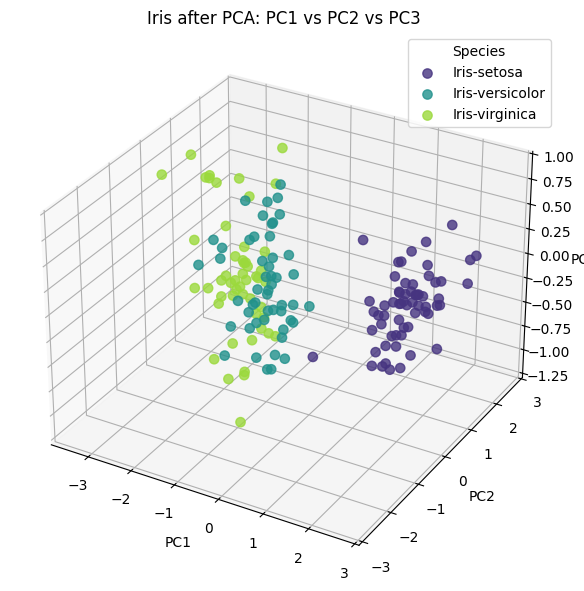

In [58]:
# Build and visualize PCA results
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
df_pca["species"] = df_iris_clean["species"].values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for species, color in species_palette.items():
    subset = df_pca[df_pca["species"] == species]
    ax.scatter(subset["PC1"], subset["PC2"], subset["PC3"], 
               label=species, color=color, s=45, alpha=0.8)

ax.set(title="Iris after PCA: PC1 vs PC2 vs PC3", xlabel="PC1", ylabel="PC2")
ax.set_zlabel("PC3")
ax.legend(title="Species")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
    <b>Hands-on:</b> Compare the before/after plots. Which species appears most separable in the PCA space?
</div>

## Resources

More about Pandas
* Pandas documentation (https://pandas.pydata.org/docs/user_guide/10min.html)
* Expand your skills (https://www.kaggle.com/learn/pandas)
* More on Pandas (https://realpython.com/pandas-python-explore-dataset/)

Imputation methods:
* Flexible Imputation of Missing Data by Stef van Buuren (https://stefvanbuuren.name/fimd/) - Code examples in R
* Scikit-learn documentation (https://scikit-learn.org/stable/modules/impute.html)

Learn about regular expressions:
* Regular expressions in Python (https://realpython.com/regex-python/)
* Build and test regular expressions (https://regex101.com/)
* Regex cheat sheet (https://www.rexegg.com/regex-quickstart.html)

Finally, tools change:
* Pandas vs. Polars (https://studioterabyte.nl/en/blog/polars-vs-pandas)
* Polars tutorial (https://www.codemag.com/Article/2212051/Using-the-Polars-DataFrame-Library)

## Thanks for tuning in!

Joan Zheng

QCL Graduate Fellow

joan.zheng@claremontmckenna.edu